## Data processing code. 

1. Look at data, exploration
2. train dataset, machine learning. 
3. Model is ready!

In [59]:
import sklearn as sk
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV




In [60]:
# Load the dataset 
data = pd.read_csv('ect_remission_synthetic.csv')
# Display the first few rows of the dataset
print(data.head())

# Print column names
print(data.columns)

      Sex AgeGroup MaritalStatus    Education DepressionType  \
0  Female    61-70       Married    >12 years       Unipolar   
1    Male    61-70       Married  10-12 years       Unipolar   
2    Male    18-30     Unmarried     ≤9 years       Unipolar   
3  Female    71-80       Married    >12 years        Bipolar   
4  Female    51-60      Divorced    >12 years        Bipolar   

   PsychoticFeatures  SubstanceUse  PersonalityDisorder  AnxietyDisorder  \
0                  0             0                    0                0   
1                  0             0                    1                0   
2                  0             0                    0                0   
3                  0             0                    0                1   
4                  0             0                    0                0   

  InitialSetting     Coercion  AntidepressantMedication  Lithium  Lamotrigine  \
0      Inpatient    Voluntary                         1        0            0

In [61]:
# Split into features and target, remission is what I want to predict
X = data.drop('Remission', axis=1)
y = data['Remission']

# Split into training ,validating and testing sets
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3 ,random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}, Testing set size: {X_valtest.shape}")

# Further split validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42, stratify=y_valtest)
print(f"Validation set size: {X_val.shape}, Testing set size: {X_test.shape}")



Training set size: (5600, 15), Testing set size: (2400, 15)
Validation set size: (1200, 15), Testing set size: (1200, 15)


### Data exploration
Goal is to gain an understanding of the data and its population. 

       PsychoticFeatures  SubstanceUse  PersonalityDisorder  AnxietyDisorder  \
count        5600.000000   5600.000000          5600.000000      5600.000000   
mean            0.178214      0.205179             0.128750         0.324464   
std             0.382727      0.403868             0.334953         0.468216   
min             0.000000      0.000000             0.000000         0.000000   
25%             0.000000      0.000000             0.000000         0.000000   
50%             0.000000      0.000000             0.000000         0.000000   
75%             0.000000      0.000000             0.000000         1.000000   
max             1.000000      1.000000             1.000000         1.000000   

       AntidepressantMedication      Lithium  Lamotrigine    Valproate  
count               5600.000000  5600.000000  5600.000000  5600.000000  
mean                   0.873929     0.159464     0.097500     0.026786  
std                    0.331959     0.366141     0.296664   

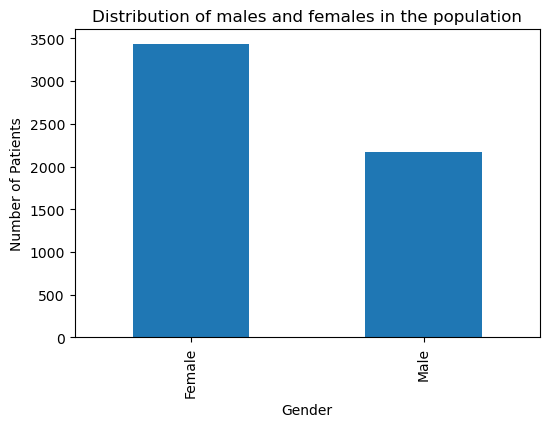

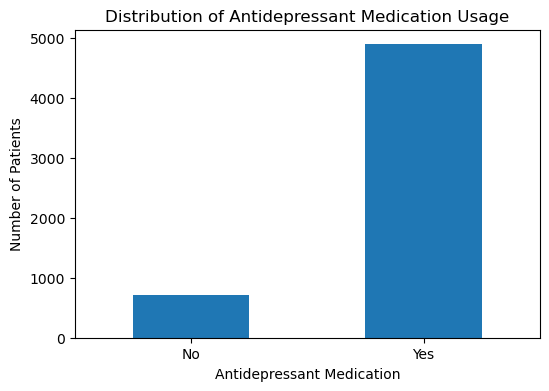

In [62]:
# For data exploration, only training data is used to avoid data leakage

# Summary statistics
print(X_train.describe())

# Men and women distribution
genderCounts = X_train['Sex'].value_counts()
plt.figure(figsize=(6,4))
genderCounts.plot(kind='bar')
plt.title('Distribution of males and females in the population')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()

# Antidepressant medication usage distribution
med_counts = X_train["AntidepressantMedication"].map({0: "No", 1: "Yes"}).value_counts()
med_counts = med_counts.reindex(["No", "Yes"])
plt.figure(figsize=(6,4))
med_counts.plot(kind="bar")
plt.title("Distribution of Antidepressant Medication Usage")
plt.xlabel("Antidepressant Medication")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()





## Choosing features to use

Before training I want to drop some features so that there is not so many questions on the web-application. Therefore I need to figure out which features contribute the most/are most important for the result. 

In [63]:
# Using one hot encoding for categorical variables ensures that no ordinal relationship is assumed between categories
categorical = [
    "Sex",
    "AgeGroup",
    "MaritalStatus",
    "Education",
    "DepressionType",
    "InitialSetting",
    "Coercion"
]

binary = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical),
        ("bin", "passthrough", binary)
    ]
)

### Baseline model
Using logistic regression L1 Lasso for my first feature selection. This model works well with binary outcomes, which is what the regression feature is, and the dataset also contains a lot of binary features.

In [64]:
lasso_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000
    ))
])

lasso_model.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Extracting the features from the L1 Lasso


In [65]:
feature_names = (
    lasso_model.named_steps["prep"]
    .get_feature_names_out()
)

coefs = lasso_model.named_steps["clf"].coef_[0]

selected = feature_names[np.abs(coefs) > 0]
selected

array(['cat__Sex_Male', 'cat__AgeGroup_31-40', 'cat__AgeGroup_41-50',
       'cat__AgeGroup_51-60', 'cat__AgeGroup_61-70',
       'cat__AgeGroup_71-80', 'cat__AgeGroup_81-95',
       'cat__MaritalStatus_Married', 'cat__MaritalStatus_Unmarried',
       'cat__MaritalStatus_Widowed', 'cat__Education_>12 years',
       'cat__Education_≤9 years', 'cat__InitialSetting_Outpatient',
       'cat__Coercion_Voluntary', 'bin__PsychoticFeatures',
       'bin__SubstanceUse', 'bin__PersonalityDisorder',
       'bin__AnxietyDisorder', 'bin__AntidepressantMedication',
       'bin__Lithium', 'bin__Lamotrigine', 'bin__Valproate'], dtype=object)

### Second model : Random forest. 
I also want to try the random forest model, as this captures non-linear effects and can capture interactions within the features. 

In [66]:
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ))
])

rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
importances = rf.named_steps["rf"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
0,cat__Sex_Male,0.084068
12,cat__DepressionType_Unipolar,0.065567
10,cat__Education_>12 years,0.065102
7,cat__MaritalStatus_Married,0.055630
8,cat__MaritalStatus_Unmarried,0.052351
13,cat__InitialSetting_Outpatient,0.052025
18,bin__AnxietyDisorder,0.050967
16,bin__SubstanceUse,0.049957
17,bin__PersonalityDisorder,0.048999
11,cat__Education_≤9 years,0.048486


### Permutaion importance
This is a robust, model-agnostic technique which measures a features impact on a model by shuffling the values and observing if there is a drop in the models score. If there is a drop, it means that the feature is important. Bigger drop -> more important.

In [68]:
r = permutation_importance(
    rf, X_train, y_train,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)

,feature,importance
1,AgeGroup,0.304528
2,MaritalStatus,0.181567
3,Education,0.173006
8,AnxietyDisorder,0.117612
0,Sex,0.105887
5,PsychoticFeatures,0.085981
6,SubstanceUse,0.079903
4,DepressionType,0.067097
12,Lithium,0.061565
11,AntidepressantMedication,0.051896


### Combining the different results to choose the features
Now that we have 3 feature selection results I can go ahead and choose which to use based on the results. 
Goal is to have around 7-8 features to use, as this is not too many questions, but it should be enough to caputre important information and get a profile on what kind of patient it is.

Based on feature selection, these features seems to have the most importance and makes sense to fill in the form on the website: 

--> Age

--> Gender

--> Tried antidepressants?

--> Depression type (Unipolar or bipolar type)

--> Coercion

--> Initial setting / Inpatient or outpatient

--> Psychotic features

--> Personality disorder

## Model selection

- Choosing models to use, fitting to training data and validation data, choosing the best one to go further with to the test data.

Choosing to use simple models that does not take long time to train. Start with 3 models and choose which one is performing the best based on validation data. 

#### Choice of models
--> Random forest 

-->Logistic regression

-->Gradient boosting


In [69]:
selected_features = [
    "AgeGroup",
    "Sex",
    "DepressionType",
    "PsychoticFeatures",
    "PersonalityDisorder",
    "AnxietyDisorder",
    "InitialSetting",
    "Coercion"
]

X_reduced = data[selected_features]
y = data["Remission"]

print (X_reduced.head())


  AgeGroup     Sex DepressionType  PsychoticFeatures  PersonalityDisorder  \
0    61-70  Female       Unipolar                  0                    0   
1    61-70    Male       Unipolar                  0                    1   
2    18-30    Male       Unipolar                  0                    0   
3    71-80  Female        Bipolar                  0                    0   
4    51-60  Female        Bipolar                  0                    0   

   AnxietyDisorder InitialSetting     Coercion  
0                0      Inpatient    Voluntary  
1                0     Outpatient    Voluntary  
2                0      Inpatient  Involuntary  
3                1      Inpatient    Voluntary  
4                0      Inpatient  Involuntary  


In [70]:
for col in selected_features:
    print(col)
    print(pd.crosstab(data[col], data["Remission"], normalize="index"))
    print()

AgeGroup
Remission         0         1
AgeGroup                     
18-30      0.675926  0.324074
31-40      0.629630  0.370370
41-50      0.647696  0.352304
51-60      0.640535  0.359465
61-70      0.496341  0.503659
71-80      0.497996  0.502004
81-95      0.276471  0.723529

Sex
Remission         0         1
Sex                          
Female     0.576192  0.423808
Male       0.577654  0.422346

DepressionType
Remission              0         1
DepressionType                    
Bipolar         0.569886  0.430114
Unipolar        0.578431  0.421569

PsychoticFeatures
Remission                 0         1
PsychoticFeatures                    
0                  0.599665  0.400335
1                  0.471289  0.528711

PersonalityDisorder
Remission                   0         1
PersonalityDisorder                    
0                    0.568743  0.431257
1                    0.630814  0.369186

AnxietyDisorder
Remission               0         1
AnxietyDisorder                    

In [71]:
#Split new dataset into training, validation and testing sets 70/15/15
X_train, X_valtest, y_train, y_valtest = train_test_split(X_reduced, y, test_size=0.3, random_state=42, stratify=y)
# Further split validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42, stratify=y_valtest)

#Print shape to see if splits are correct, should be 70/15/15 and total should equal (2000, 7)
print (f"Training set size: {X_train.shape}, Validation set size: {X_val.shape}, Testing set size: {X_test.shape}")


Training set size: (5600, 8), Validation set size: (1200, 8), Testing set size: (1200, 8)


In [72]:
#Convert agegroup to midpoint, this will represent the age group as a value instead of a category.

def age_midpoint(age_group):
    if "+" in age_group:
        return int(age_group.replace("+","")) + 5
    if "-" in age_group:
        low, high = age_group.split("-")
        return (int(low) + int(high)) / 2
    return np.nan

X_train["AgeGroup"] = X_train["AgeGroup"].apply(age_midpoint)
X_val["AgeGroup"] = X_val["AgeGroup"].apply(age_midpoint)
X_test["AgeGroup"] = X_test["AgeGroup"].apply(age_midpoint)

## Model selection pipeline

Splitting the features into two different categories : Categorical and numeric. This is because the dataset cointains both strings and float values. Because common models cannot handle strings, it is necessary to encode them. I also decided to use a pipeline to ensure efficiency, reprodicibility and consistency.

In [73]:
categorical_cols = [
    "Sex",
    "DepressionType",
    "InitialSetting",
    "Coercion"
]

numeric_cols = [
    "AgeGroup",
    "AnxietyDisorder",
    "PsychoticFeatures",
    "PersonalityDisorder"
]

In [74]:
print (X_train.columns)

Index(['AgeGroup', 'Sex', 'DepressionType', 'PsychoticFeatures',
       'PersonalityDisorder', 'AnxietyDisorder', 'InitialSetting', 'Coercion'],
      dtype='object')


In [75]:
print(y_train.value_counts(normalize=True))

Remission
0    0.576786
1    0.423214
Name: proportion, dtype: float64


In [76]:
preprocessor_model = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_transformed = preprocessor_model.fit_transform(X_train)
print(X_transformed.shape)

(5600, 8)


### Random forest 
Random forest is an ensemble model which captures nonlinear relationships. It creates different decision trees and combines the prediction from the trees to create a single tree. 

In [77]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("prep", preprocessor_model),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

grid_rf = {
    "rf__n_estimators": [100, 200, 500],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 5]
}

bestmodel_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

bestmodel_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", bestmodel_rf.best_params_)


Best parameters for Random Forest: {'rf__max_depth': 10, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


### Logistic regression
Logistic regression is a linear model which captures linear relationships by examining the relationship between the features and the target variable. It is different from linear regression by predicting categorical outcome instead of continous values. Well suited in this task because we are prediciting remission or no remission. 

In [78]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ("prep", preprocessor_model),
    ("lr", LogisticRegression(max_iter=5000))
])

grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__penalty": ["l2"]
}

bestmodel_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=grid_lr,
    cv=5,
    n_jobs=-1,
    scoring="roc_auc"
)

bestmodel_lr.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", bestmodel_lr.best_params_)

Best parameters for Logistic Regression: {'lr__C': 0.1, 'lr__penalty': 'l2'}


### Gradient boosting
Gradient boosting is a enseble model which builds a strong model by combining other weak models, training to minimize loss function. After each iteration of computing the gradient of the loss function, the weak model is added to the ensemble and a new weak model is being trained to predict the gradient until a stop criterion is met. 

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([
    ("prep", preprocessor_model),
    ("gb", GradientBoostingClassifier())
])

grid_gb = {
    "gb__n_estimators": [100, 200],
    "gb__learning_rate": [0.01, 0.1],
    "gb__max_depth": [2, 3]
}

bestmodel_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=grid_gb,
    cv=5,
    n_jobs=-1,
    scoring="roc_auc"
)

bestmodel_gb.fit(X_train, y_train)

print("Best parameters for Gradient Boosting:", bestmodel_gb.best_params_)


Best parameters for Gradient Boosting: {'gb__learning_rate': 0.1, 'gb__max_depth': 2, 'gb__n_estimators': 100}


### Finding out the best model
Use validation data to evaluate which model is performing the best. Avoiding underfitting and overfitting. This model is then being used on the test data, and used for the project further to evaluate new unseen data plotted into the web application.

In [80]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic": bestmodel_lr,
    "RandomForest": bestmodel_rf,
    "GradientBoost": bestmodel_gb
}

### Results from validation data 


In [81]:
results = []

for name, model in models.items():
    probs = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, probs)
    results.append((name, auc))

results_df = pd.DataFrame(results, columns=["Model", "ROC_AUC"])
print(results_df.sort_values("ROC_AUC", ascending=False))

           Model   ROC_AUC
2  GradientBoost  0.658401
0       Logistic  0.651878
1   RandomForest  0.640445


In [82]:
#Automate the evaluation of the best model on the test set
best_model_name, best_model_auc = max(results, key=lambda x: x[1])
print(f"Best model: {best_model_name} with AUC: {best_model_auc:.4f}")

best_model = models[best_model_name]


Best model: GradientBoost with AUC: 0.6584


## Visualization of results + final result on test data

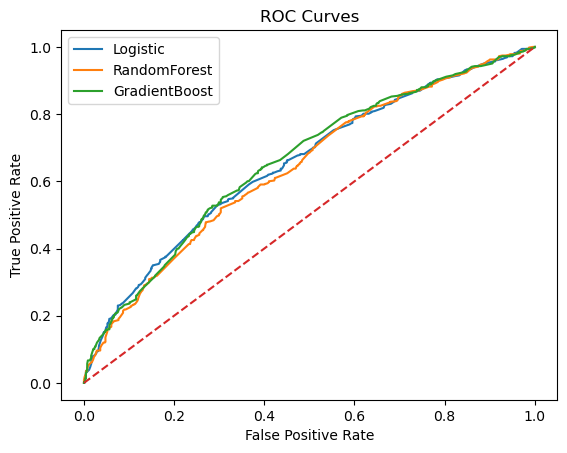

In [83]:
from sklearn.metrics import roc_curve

for name, model in models.items():
    probs = model.predict_proba(X_val)[:,1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

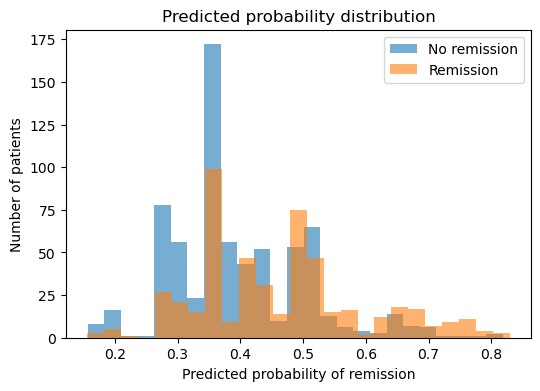

In [84]:
probs = best_model.predict_proba(X_val)[:,1]

plt.figure(figsize=(6,4))

plt.hist(probs[y_val==0], bins=25, alpha=0.6, label="No remission")
plt.hist(probs[y_val==1], bins=25, alpha=0.6, label="Remission")

plt.xlabel("Predicted probability of remission")
plt.ylabel("Number of patients")
plt.title("Predicted probability distribution")
plt.legend()

plt.show()

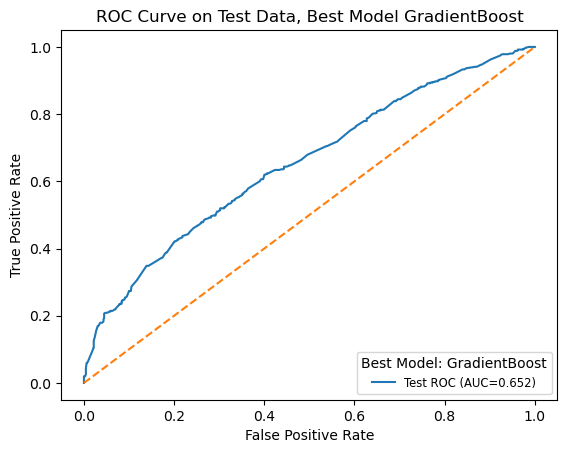

Test AUC for best model GradientBoost: 0.6520


In [85]:
probs_test = best_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, probs_test)

plt.plot(fpr, tpr, label=f"Test ROC (AUC={roc_auc_score(y_test, probs_test):.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Data, Best Model " + best_model_name)
#Add legend to show AUC score
plt.legend( loc="lower right", fontsize="small", title="Best Model: " + best_model_name)


plt.show()

print (f"Test AUC for best model {best_model_name}: {roc_auc_score(y_test, probs_test):.4f}")

In [86]:
#Save model for use in app.py
import pickle as pk

best_model.fit(X_train, y_train)

with open("model.pkl", "wb") as f:
    pk.dump(best_model, f)